## Heart Disease Risk Analysis

Cardiovascular diseases (CVDs) are the first cause of deaths worldwide, taking nearly 17.9M lives each year which represent 31% of global deaths. 4 of 5 deaths by CVDs are due to heart attacks and cardiovascular accidents and a third of it on people under 70 years old. Heart failure are commonly caused by CVDs and this dataset contained 11 features used to predict a posible heart disease.

People with CVDs o high cardiovascular risk (diabetes, high blood pressure, hyperlipidemia or preexisting condition) require early detection and management where a machine learning model can be helpfull.

Content
1. Age: Pacient age [years]
2. Sex = M: Male, 
         F: Female
3. ChestPainType =  TA: Angina Típica, 
                    ATA: Angina Atípica, 
                    NAP: Dolor No-Anginal, 
                    ASY: Asintomática
4. RestingBP: Resting Blood Presure [mm Hg]
5. Cholesterol [mm/dl]
6. FastingBS: Fasting Blood Sugar [1: if FastingBS > 120 mg/dl, 0: other case]
7. RestingECG: Resting Electrocardiogram [Normal: Normal, ST: Strain Pattern, LVH: Left Ventricular Hypertrophy]
8. MaxHR: Max Heart Rate [Numeric value between 60 y 202]
9. ExerciseAngina: Angina induce by exercise [Y: Yes, N: No]
10. Oldpeak: Numeric value of the degree of exercise-induced ST segment depression relative to rest
11. ST_Slope: Slope segment ST of max exercise [Up, Flat, Down]
12. HeartDisease: target [1: cardiopathy, 0: Normal]

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\usuario\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [67]:
df = pd.read_csv("heart_2.csv")
df.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


## 1. Data Understanding

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [69]:
print(f'\nDuplicated: {df.duplicated().sum()}\n')


Duplicated: 0



In [70]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [71]:
(pd.DataFrame({
    "Condition": ["Cholesterol = 0", "RestingBP = 0", "Oldpeak < 0"],
    "Percentage": [
        (df["Cholesterol"]==0).mean()*100,
        (df["RestingBP"]==0).mean()*100,
        (df["Oldpeak"]<0).mean()*100
    ]
}).round(2))

,Condition,Percentage
0,Cholesterol = 0,18.74
1,RestingBP = 0,0.11
2,Oldpeak < 0,1.42


## 2. Data Cleaning

In [72]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df = df.dropna(subset=["RestingBP"])
df = df[df["Oldpeak"]>=0]

In [73]:
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].fillna(df['Cholesterol'].median())

In [74]:
categoric_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
for col in categoric_cols:
    print(f"{col}: {df[col].unique()}")

Sex: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType: <ArrowStringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG: <ArrowStringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope: <ArrowStringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


In [ ]:
# Encoding
binary_cols = ["Sex", "ExerciseAngina"]
for bin in binary_cols:
    df[bin] = df[bin].map({"M":1, "F":0}) if bin=="Sex" else df[bin].map({"Y":1, "N":0})

noBinary_cols = ["ChestPainType", "RestingECG", "ST_Slope"]
df = pd.get_dummies(df, columns=noBinary_cols, drop_first=True)

# Convert bool to int
dummy_cols = df.select_dtypes(include="bool").columns
df[dummy_cols] = df[dummy_cols].astype(int)
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,0,1,0,1,0,0,1


In [ ]:
# Final check
print(df.isnull().sum())

Age                  0
Sex                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
ExerciseAngina       0
Oldpeak              0
HeartDisease         0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_Normal    0
RestingECG_ST        0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64


In [77]:
df.sample(5).T

,397,833,356,71,93
Age,58.0,54.0,46.0,44.0,48.0
Sex,1.0,1.0,1.0,1.0,1.0
RestingBP,170.0,120.0,115.0,130.0,160.0
Cholesterol,237.0,258.0,237.0,215.0,329.0
FastingBS,1.0,0.0,0.0,0.0,0.0
MaxHR,105.0,147.0,113.0,135.0,92.0
ExerciseAngina,1.0,0.0,1.0,0.0,1.0
Oldpeak,0.0,0.4,1.5,0.0,1.5
HeartDisease,1.0,0.0,1.0,0.0,1.0
ChestPainType_ATA,0.0,0.0,0.0,1.0,0.0


Values equal to 0 in _RestingBP_ and negative values in _Oldpeak_ are considered inconsistent with their clinical definitions and likely correspond to data entry or measurement errors. Given their very low proportion in the dataset (0.1% and 1.4%, respectively), these observations were removed, as their impact on the overall distribution is negligible.

In contrast, approximately 19% of the values in _Cholesterol_ are equal to 0. Removing these observations would significantly reduce the dataset and potentially introduce bias. Therefore, these values were treated as missing and imputed using the median, which is robust to outliers. The unusually high proportion of zero values in _Cholesterol_ suggests a potential systematic recording issue or placeholder value, rather than true physiological measurements.

Categorical variables were encoded using one-hot encoding. Resulting boolean features were converted to integer format (0/1) for compatibility and interpretability.

I used one-hot encoding with _drop first=True_ to avoid multicollinearity. The dropped category acts as a baseline, and when all dummy variables are zero, the observation belongs to that reference category.

After the cleaning there is no null or empty data.

In [ ]:
# Save
df.to_csv("heart_cleaned.csv", index=False)

## Análisis outliers

Cholesterol

In [16]:
# Análisis de valores faltantes en CHOLESTEROL
print("=== ANÁLISIS DE LA VARIABLE CHOLESTEROL ===")
print(f"Total de registros: {len(df)}")
print(f"Valores faltantes en Cholesterol: {df["Cholesterol"].isnull().sum()}")
print(f"Porcentaje de valores faltantes: {(df["Cholesterol"].isnull().sum() / len(df)) * 100:.2f}%")
print(f"Valores disponibles para análisis: {df["Cholesterol"].notna().sum()}")

=== ANÁLISIS DE LA VARIABLE CHOLESTEROL ===
Total de registros: 904
Valores faltantes en Cholesterol: 0
Porcentaje de valores faltantes: 0.00%
Valores disponibles para análisis: 904


In [56]:
# Estadísticas descriptivas de CHOLESTEROL
Cholesterol_stats = df["Cholesterol"].describe()
print("=== ESTADÍSTICAS DESCRIPTIVAS DE CHOLESTEROL ===")
print(Cholesterol_stats)
print(f"\nModa: {df["Cholesterol"].mode().iloc[0]:.2f} [mm/dl]")
print(f"Desviación estándar: {df["Cholesterol"].std():.2f} [mm/dl]")
print(f"Rango: {df["Cholesterol"].max() - df["Cholesterol"].min():.2f} [mm/dl]")
print(f"Coeficiente de variación: {(df["Cholesterol"].std() / df["Cholesterol"].mean()) * 100:.2f}%")


=== ESTADÍSTICAS DESCRIPTIVAS DE CHOLESTEROL ===
count    904.000000
mean     243.384956
std       53.738632
min       85.000000
25%      214.000000
50%      237.000000
75%      268.000000
max      603.000000
Name: Cholesterol, dtype: float64

Moda: 237.00 [mm/dl]
Desviación estándar: 53.74 [mm/dl]
Rango: 518.00 [mm/dl]
Coeficiente de variación: 22.08%


Al analizar la moda y cuartiles, se puede detectar una distribución de datos con valores atípicos, por lo que se realizará un análisis de valores atípicos o outliers.

In [18]:
# Análisis de cuartiles y percentiles para CHOLESTEROL
print("=== ANÁLISIS DE CUARTILES Y PERCENTILES DE CHOLESTEROL ===")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = np.percentile(df["Cholesterol"].dropna(), p)
    print(f"Percentil {p}: {value:.2f} [mm/dl]")

# Identificar valores atípicos
Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Análisis de valóres atípicos o outliers
outliers = df[(df["Cholesterol"] < lower_bound) | (df["Cholesterol"] > upper_bound)]["Cholesterol"]
print(f"\n=== VALORES ATÍPICOS ===")
print(f"Límite inferior: {lower_bound:.2f} [mm/dl]")
print(f"Límite superior: {upper_bound:.2f} [mm/dl]")
print(f"Número de valores atípicos: {len(outliers)}")
print(f"Porcentaje de valores atípicos: {(len(outliers) / len(df)) * 100:.2f}%")

=== ANÁLISIS DE CUARTILES Y PERCENTILES DE CHOLESTEROL ===
Percentil 10: 186.00 [mm/dl]
Percentil 25: 214.00 [mm/dl]
Percentil 50: 237.00 [mm/dl]
Percentil 75: 268.00 [mm/dl]
Percentil 90: 305.70 [mm/dl]
Percentil 95: 332.70 [mm/dl]
Percentil 99: 411.91 [mm/dl]

=== VALORES ATÍPICOS ===
Límite inferior: 133.00 [mm/dl]
Límite superior: 349.00 [mm/dl]
Número de valores atípicos: 39
Porcentaje de valores atípicos: 4.31%


A partir del análisis de valores atípicos tenemos 39 datos en este rango, correspondientes al 4.31% del total de datos. 
Por lo que realizaremos la visualización de los datos para un análisis visual.

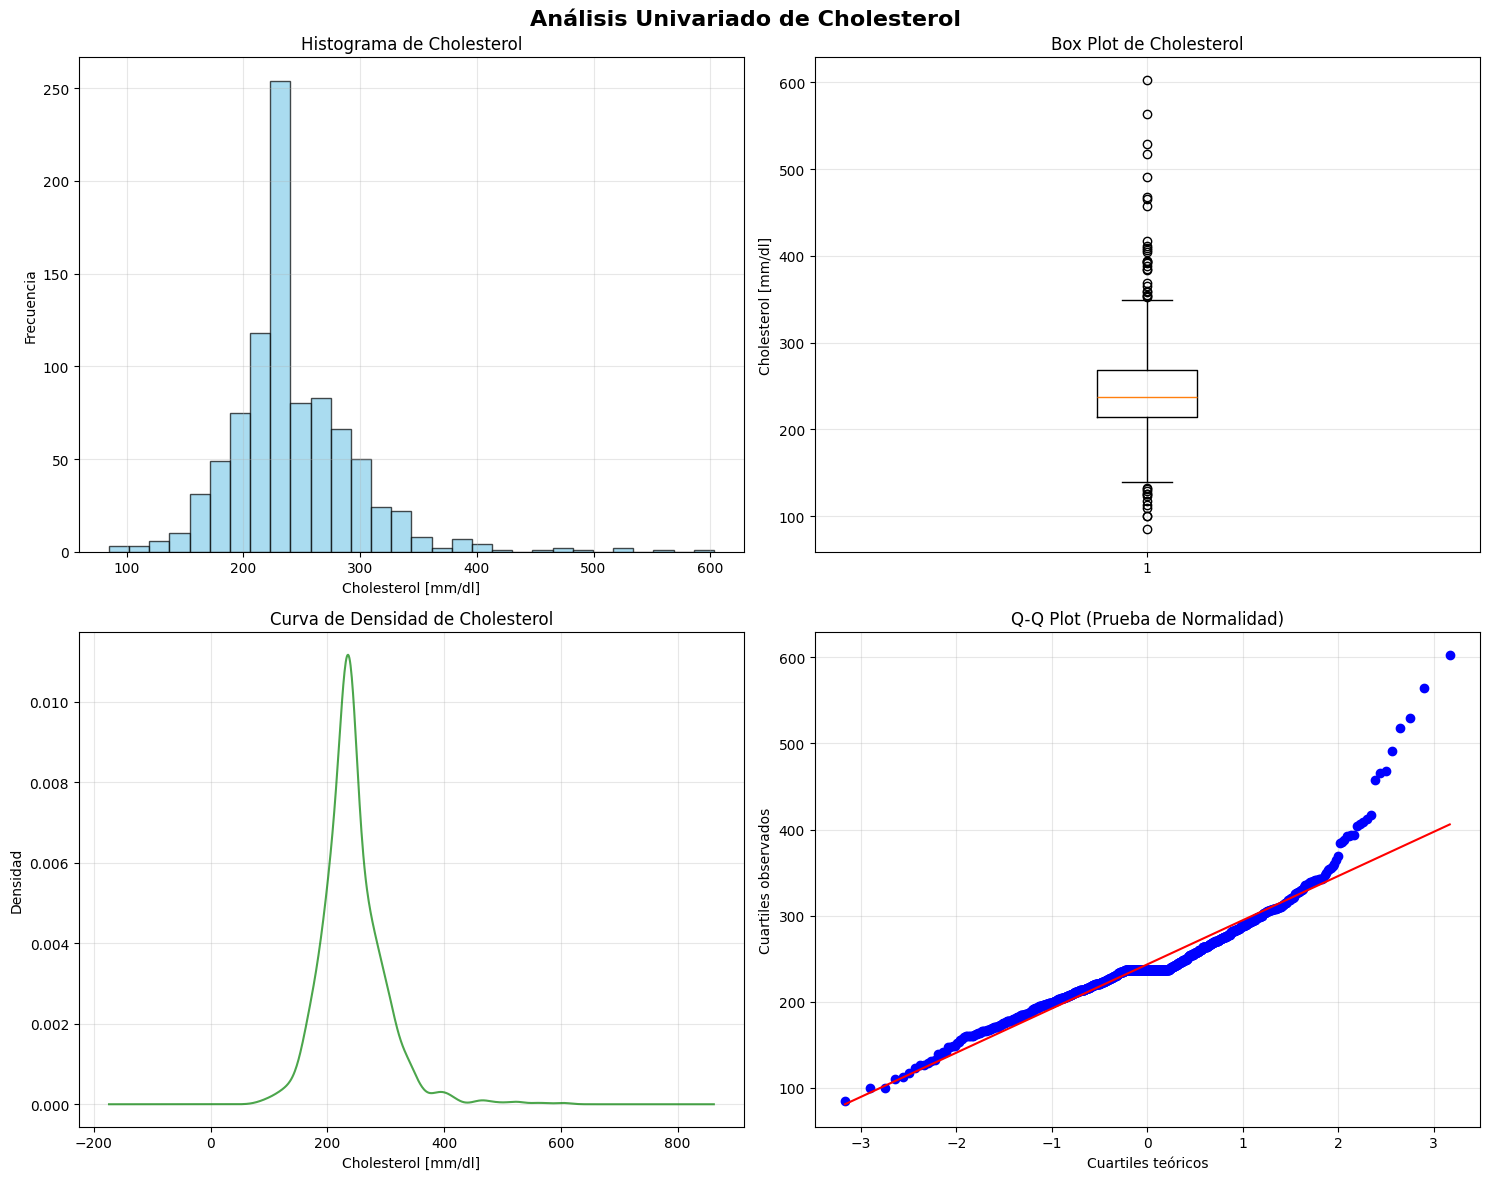

In [19]:
# Visualización de la distribución de Cholesterol
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis Univariado de Cholesterol', fontsize=16, fontweight='bold')

# Histograma
axes[0, 0].hist(df["Cholesterol"].dropna(), bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title("Histograma de Cholesterol")
axes[0, 0].set_xlabel("Cholesterol [mm/dl]")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(df["Cholesterol"].dropna(), vert=True)
axes[0, 1].set_title("Box Plot de Cholesterol")
axes[0, 1].set_ylabel("Cholesterol [mm/dl]")
axes[0, 1].grid(True, alpha=0.3)

# Gráfico de densidad
df["Cholesterol"].dropna().plot(kind='density', ax=axes[1, 0], color='green', alpha=0.7)
axes[1, 0].set_title("Curva de Densidad de Cholesterol")
axes[1, 0].set_xlabel("Cholesterol [mm/dl]")
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q Plot para normalidad
stats.probplot(df["Cholesterol"].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Prueba de Normalidad)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('Cuartiles teóricos')
axes[1, 1].set_ylabel('Cuartiles observados')

plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import shapiro, normaltest

# Usamos el DataFrame limpio
data = df['Cholesterol']
print("\nVARIABLE: Cholesterol")
print("-" * 40)
# --- Aplicación del Test de Shapiro-Wilk (Ideal para muestras pequeñas/medianas) y D'Agostino y Pearson---

# H0: La distribución es Normal.
# Ha: La distribución NO es Normal.

if len(data) <= 5000:
    shapiro_stat, shapiro_p = shapiro(data.sample(5000) if len(data) > 5000 else data)
    print(f"Shapiro-Wilk: estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")

dagostino_stat, dagostino_p = normaltest(data)
print(f"D'Agostino-Pearson: estadístico={dagostino_stat:.4f}, p-valor={dagostino_p:.4f}")

print("\n=== INTERPRETACIÓN ===")
print("p-valor < 0.05: Rechazar H0 (no es normal)")
print("p-valor >= 0.05: No rechazar H0 (puede ser normal)")


VARIABLE: Cholesterol
----------------------------------------
Shapiro-Wilk: estadístico=0.9092, p-valor=0.0000
D'Agostino-Pearson: estadístico=307.0264, p-valor=0.0000

=== INTERPRETACIÓN ===
p-valor < 0.05: Rechazar H0 (no es normal)
p-valor >= 0.05: No rechazar H0 (puede ser normal)


El análisis visual (histograma, KDE, boxplot y Q-Q plot) junto con los tests de normalidad (Shapiro-Wilk y D’Agostino-Pearson) indican que la variable *Cholesterol* no sigue una distribución normal.

Se observa una asimetría positiva (sesgo a la derecha), evidenciada por la cola larga hacia valores altos y la presencia de múltiples outliers en el extremo superior. Esto sugiere que existen individuos con niveles de colesterol considerablemente más altos que la media, lo cual es consistente con poblaciones con riesgo cardiovascular elevado.

La desviación en el Q-Q plot, especialmente en los cuantiles superiores, refuerza la presencia de colas pesadas, alejándose del comportamiento gaussiano.

Dado que la variable es continua, podría explorarse una transformación (por ejemplo, logarítmica) o evaluar distribuciones alternativas como la log-normal.

Implicaciones para el modelado:

Modelos sensibles a la normalidad (como regresión lineal clásica) podrían verse afectados.
Se recomienda evaluar transformaciones o usar modelos robustos (árboles, boosting).
Los outliers podrían contener información relevante (pacientes de alto riesgo), por lo que no deberían eliminarse sin justificación.

Oldpeak

In [22]:
# Análisis de valores faltantes en OLDPEAK
print("=== ANÁLISIS DE LA VARIABLE OLDPEAK ===")
print(f"Total de registros: {len(df)}")
print(f"Valores faltantes en Oldpeak: {df["Oldpeak"].isnull().sum()}")
print(f"Porcentaje de valores faltantes: {(df["Oldpeak"].isnull().sum() / len(df)) * 100:.2f}%")
print(f"Valores disponibles para análisis: {df["Oldpeak"].notna().sum()}")

=== ANÁLISIS DE LA VARIABLE OLDPEAK ===
Total de registros: 904
Valores faltantes en Oldpeak: 0
Porcentaje de valores faltantes: 0.00%
Valores disponibles para análisis: 904


In [23]:
# Estadísticas descriptivas de OLDPEAK
Oldpeak_stats = df["Oldpeak"].describe()
print("=== ESTADÍSTICAS DESCRIPTIVAS DE OLDPEAK ===")
print(Oldpeak_stats)
print(f"\nModa: {df["Oldpeak"].mode().iloc[0]:.2f}")
print(f"Desviación estándar: {df["Oldpeak"].std():.2f}")
print(f"Rango: {df["Oldpeak"].max() - df["Oldpeak"].min():.2f}")
print(f"Coeficiente de variación: {(df["Oldpeak"].std() / df["Oldpeak"].mean()) * 100:.2f}%")


=== ESTADÍSTICAS DESCRIPTIVAS DE OLDPEAK ===
count    904.000000
mean       0.913606
std        1.047342
min        0.000000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

Moda: 0.00
Desviación estándar: 1.05
Rango: 6.20
Coeficiente de variación: 114.64%


Al analizar la moda, cuartiles y desviación estándar, se puede detectar una distribución de datos con valores atípicos, por lo que se realizará un análisis de valores atípicos o outliers.

In [25]:
# Análisis de cuartiles y percentiles para OLDPEAK
print("=== ANÁLISIS DE CUARTILES Y PERCENTILES DE OLDPEAK ===")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = np.percentile(df["Oldpeak"].dropna(), p)
    print(f"Percentil {p}: {value:.2f}")

# Identificar valores atípicos
Q1 = df["Oldpeak"].quantile(0.25)
Q3 = df["Oldpeak"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Análisis de valóres atípicos o outliers
outliers = df[(df["Oldpeak"] < lower_bound) | (df["Oldpeak"] > upper_bound)]["Oldpeak"]
print(f"\n=== VALORES ATÍPICOS ===")
print(f"Límite inferior: {lower_bound:.2f}")
print(f"Límite superior: {upper_bound:.2f}")
print(f"Número de valores atípicos: {len(outliers)}")
print(f"Porcentaje de valores atípicos: {(len(outliers) / len(df)) * 100:.2f}%")

=== ANÁLISIS DE CUARTILES Y PERCENTILES DE OLDPEAK ===
Percentil 10: 0.00
Percentil 25: 0.00
Percentil 50: 0.60
Percentil 75: 1.50
Percentil 90: 2.37
Percentil 95: 3.00
Percentil 99: 4.00

=== VALORES ATÍPICOS ===
Límite inferior: -2.25
Límite superior: 3.75
Número de valores atípicos: 15
Porcentaje de valores atípicos: 1.66%


A partir del análisis de valores atípicos tenemos 15 datos en este rango, correspondientes al 1.66% del total de datos. 
Por lo que realizaremos la visualización de los datos para un análisis visual.

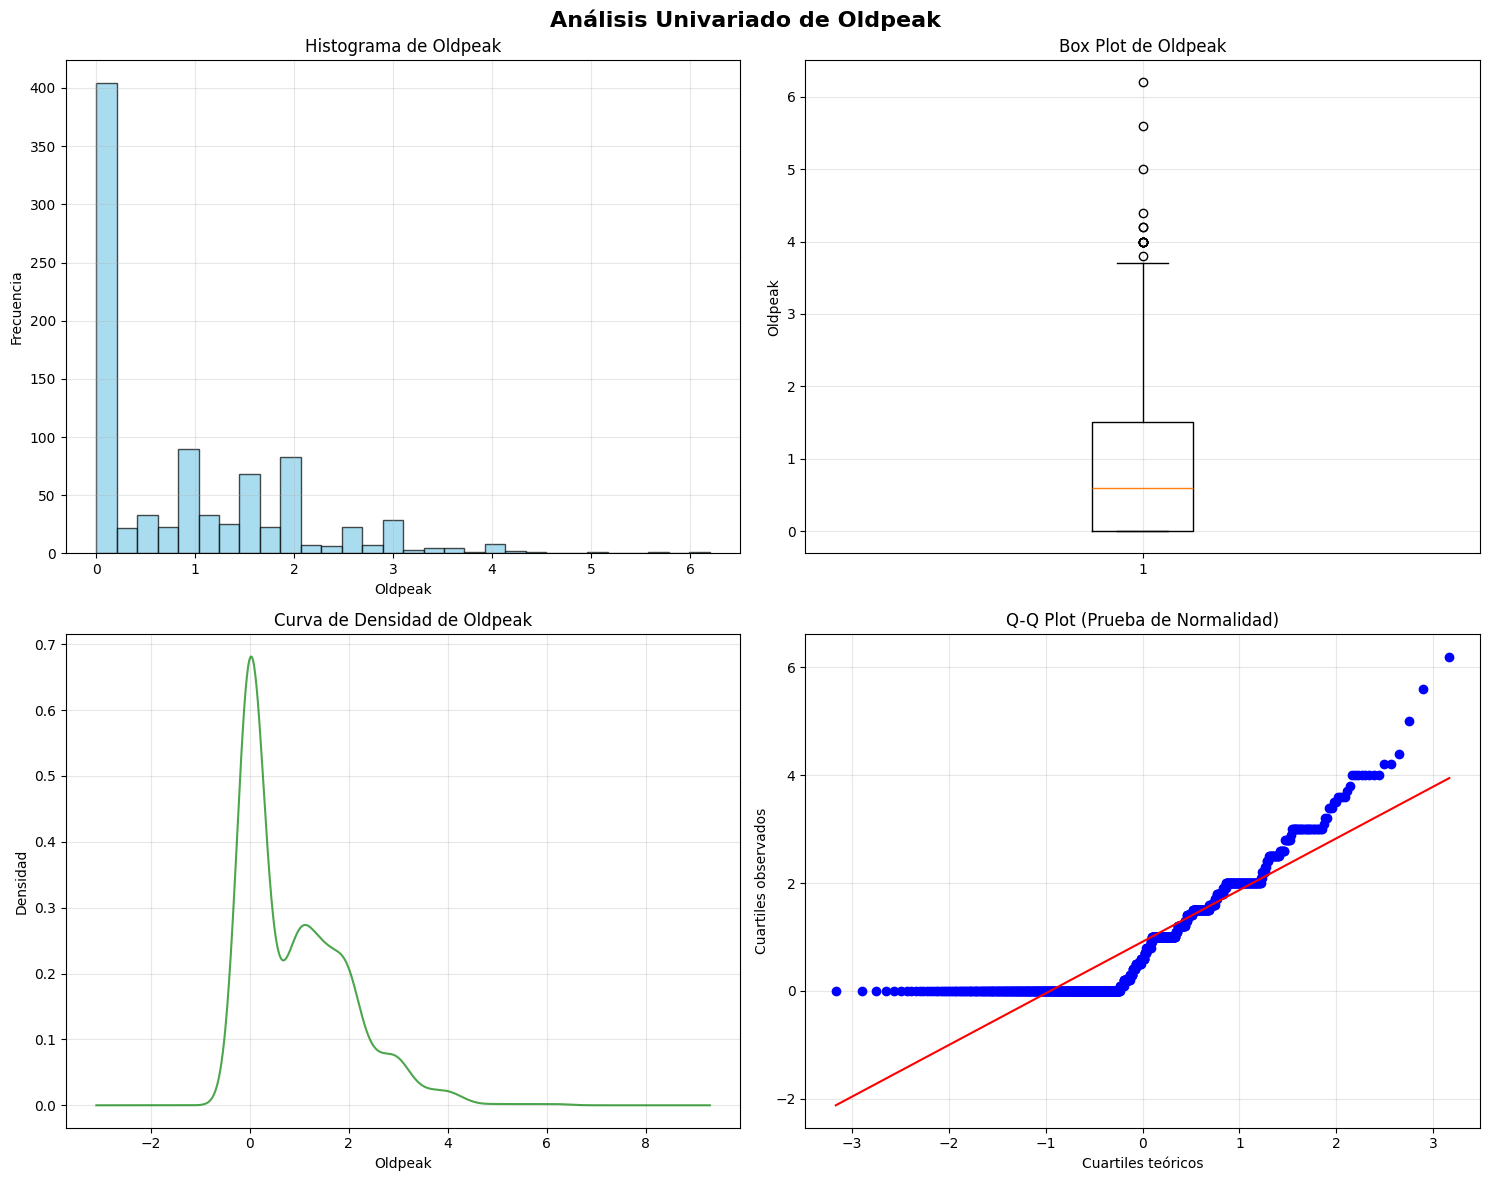

In [26]:
# Visualización de la distribución de Oldpeak
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis Univariado de Oldpeak', fontsize=16, fontweight='bold')

# Histograma
axes[0, 0].hist(df["Oldpeak"].dropna(), bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title("Histograma de Oldpeak")
axes[0, 0].set_xlabel("Oldpeak")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(df["Oldpeak"].dropna(), vert=True)
axes[0, 1].set_title("Box Plot de Oldpeak")
axes[0, 1].set_ylabel("Oldpeak")
axes[0, 1].grid(True, alpha=0.3)

# Gráfico de densidad
df["Oldpeak"].dropna().plot(kind='density', ax=axes[1, 0], color='green', alpha=0.7)
axes[1, 0].set_title("Curva de Densidad de Oldpeak")
axes[1, 0].set_xlabel("Oldpeak")
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q Plot para normalidad
stats.probplot(df["Oldpeak"].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Prueba de Normalidad)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('Cuartiles teóricos')
axes[1, 1].set_ylabel('Cuartiles observados')

plt.tight_layout()
plt.show()

In [27]:
from scipy.stats import shapiro, normaltest

# Usamos el DataFrame limpio
data = df['Oldpeak']
print("\nVARIABLE: Oldpeak")
print("-" * 40)
# --- Aplicación del Test de Shapiro-Wilk (Ideal para muestras pequeñas/medianas) y D'Agostino y Pearson---

# H0: La distribución es Normal.
# Ha: La distribución NO es Normal.

if len(data) <= 5000:
    shapiro_stat, shapiro_p = shapiro(data.sample(5000) if len(data) > 5000 else data)
    print(f"Shapiro-Wilk: estadístico={shapiro_stat:.4f}, p-valor={shapiro_p:.4f}")

dagostino_stat, dagostino_p = normaltest(data)
print(f"D'Agostino-Pearson: estadístico={dagostino_stat:.4f}, p-valor={dagostino_p:.4f}")

print("\n=== INTERPRETACIÓN ===")
print("p-valor < 0.05: Rechazar H0 (no es normal)")
print("p-valor >= 0.05: No rechazar H0 (puede ser normal)")


VARIABLE: Oldpeak
----------------------------------------
Shapiro-Wilk: estadístico=0.8313, p-valor=0.0000
D'Agostino-Pearson: estadístico=155.7216, p-valor=0.0000

=== INTERPRETACIÓN ===
p-valor < 0.05: Rechazar H0 (no es normal)
p-valor >= 0.05: No rechazar H0 (puede ser normal)


El análisis visual (histograma, KDE, boxplot y Q-Q plot) junto con los tests de normalidad (Shapiro-Wilk y D’Agostino-Pearson) indican que la variable *Oldpeak* no sigue una distribución normal.

Se observa una fuerte asimetría positiva, con una alta concentración de valores cercanos a 0 y una cola larga hacia valores elevados. Esta acumulación en cero sugiere una posible distribución cero-inflada, lo que podría reflejar la presencia de pacientes sin depresión del segmento ST frente a otros con distintos niveles de severidad.

La desviación sistemática en el Q-Q plot, especialmente en los cuantiles superiores, evidencia colas pesadas y refuerza la no normalidad de la variable.

Desde un punto de vista clínico, valores elevados de *Oldpeak* están asociados a isquemia miocárdica inducida por ejercicio, lo que indica una posible reducción en el flujo sanguíneo coronario. En este contexto, los valores extremos son clínicamente relevantes y no deberían ser tratados automáticamente como outliers a eliminar, sino como observaciones de alto interés para el modelado predictivo.

Implicaciones para el modelado:

La presencia de muchos ceros y la asimetría sugieren que transformaciones simples (como log) pueden no ser suficientes sin ajustes (ej: log(x+1)).

Podría ser útil considerar enfoques alternativos:

Discretización (bins clínicos)

Modelos robustos a outliers (árboles, boosting)

Modelos que capturen no linealidad

También es posible explorar la variable como categórica (ej: 0 vs >0), dado su posible significado clínico.

En conjunto, *Oldpeak* presenta características que requieren un tratamiento cuidadoso en etapas posteriores de modelado

### Insights outliers
- Los valores extremos en *Cholesterol* podrían representar pacientes con hipercolesterolemia severa, lo cual es relevante para la predicción de enfermedad cardíaca.
- Los valores extremos en *Oldpeak* podrían representar pacientes con isquemia miocárdica, lo cual es relevante para la predicción de enfermedad cardíaca.

## Análisis Univariado *Heart Disease*

In [28]:
# Análisis de valores faltantes en HEART DISEASE
print("=== ANÁLISIS DE LA VARIABLE HEART DISEASE ===")
print(f"Total de registros: {len(df)}")
print(f"Valores faltantes en Heart Disease: {df["HeartDisease"].isnull().sum()}")
print(f"Porcentaje de valores faltantes: {(df["HeartDisease"].isnull().sum() / len(df)) * 100:.2f}%")
print(f"Valores disponibles para análisis: {df["HeartDisease"].notna().sum()}")

=== ANÁLISIS DE LA VARIABLE HEART DISEASE ===
Total de registros: 904
Valores faltantes en Heart Disease: 0
Porcentaje de valores faltantes: 0.00%
Valores disponibles para análisis: 904


In [29]:
# Estadísticas descriptivas de HEART DISEASE
HeartDisease_stats = df["HeartDisease"].describe()
print("=== ESTADÍSTICAS DESCRIPTIVAS DE HEART DISEASE ===")
print(HeartDisease_stats)
print(f"\nModa: {df["HeartDisease"].mode().iloc[0]:.2f}")
print(f"Desviación estándar: {df["HeartDisease"].std():.2f}")
print(f"Rango: {df["HeartDisease"].max() - df["HeartDisease"].min():.2f}")
print(f"Coeficiente de variación: {(df["HeartDisease"].std() / df["HeartDisease"].mean()) * 100:.2f}%")


=== ESTADÍSTICAS DESCRIPTIVAS DE HEART DISEASE ===
count    904.000000
mean       0.550885
std        0.497679
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: HeartDisease, dtype: float64

Moda: 1.00
Desviación estándar: 0.50
Rango: 1.00
Coeficiente de variación: 90.34%


In [30]:
# Análisis de cuartiles y percentiles para HEART DISEASE
print("=== ANÁLISIS DE CUARTILES Y PERCENTILES DE HEART DISEASE ===")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = np.percentile(df["HeartDisease"].dropna(), p)
    print(f"Percentil {p}: {value:.2f}")

# Identificar valores atípicos
Q1 = df["HeartDisease"].quantile(0.25)
Q3 = df["HeartDisease"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Análisis de valóres atípicos o outliers
outliers = df[(df["HeartDisease"] < lower_bound) | (df["HeartDisease"] > upper_bound)]["Oldpeak"]
print(f"\n=== VALORES ATÍPICOS ===")
print(f"Límite inferior: {lower_bound:.2f}")
print(f"Límite superior: {upper_bound:.2f}")
print(f"Número de valores atípicos: {len(outliers)}")
print(f"Porcentaje de valores atípicos: {(len(outliers) / len(df)) * 100:.2f}%")

=== ANÁLISIS DE CUARTILES Y PERCENTILES DE HEART DISEASE ===
Percentil 10: 0.00
Percentil 25: 0.00
Percentil 50: 1.00
Percentil 75: 1.00
Percentil 90: 1.00
Percentil 95: 1.00
Percentil 99: 1.00

=== VALORES ATÍPICOS ===
Límite inferior: -1.50
Límite superior: 2.50
Número de valores atípicos: 0
Porcentaje de valores atípicos: 0.00%


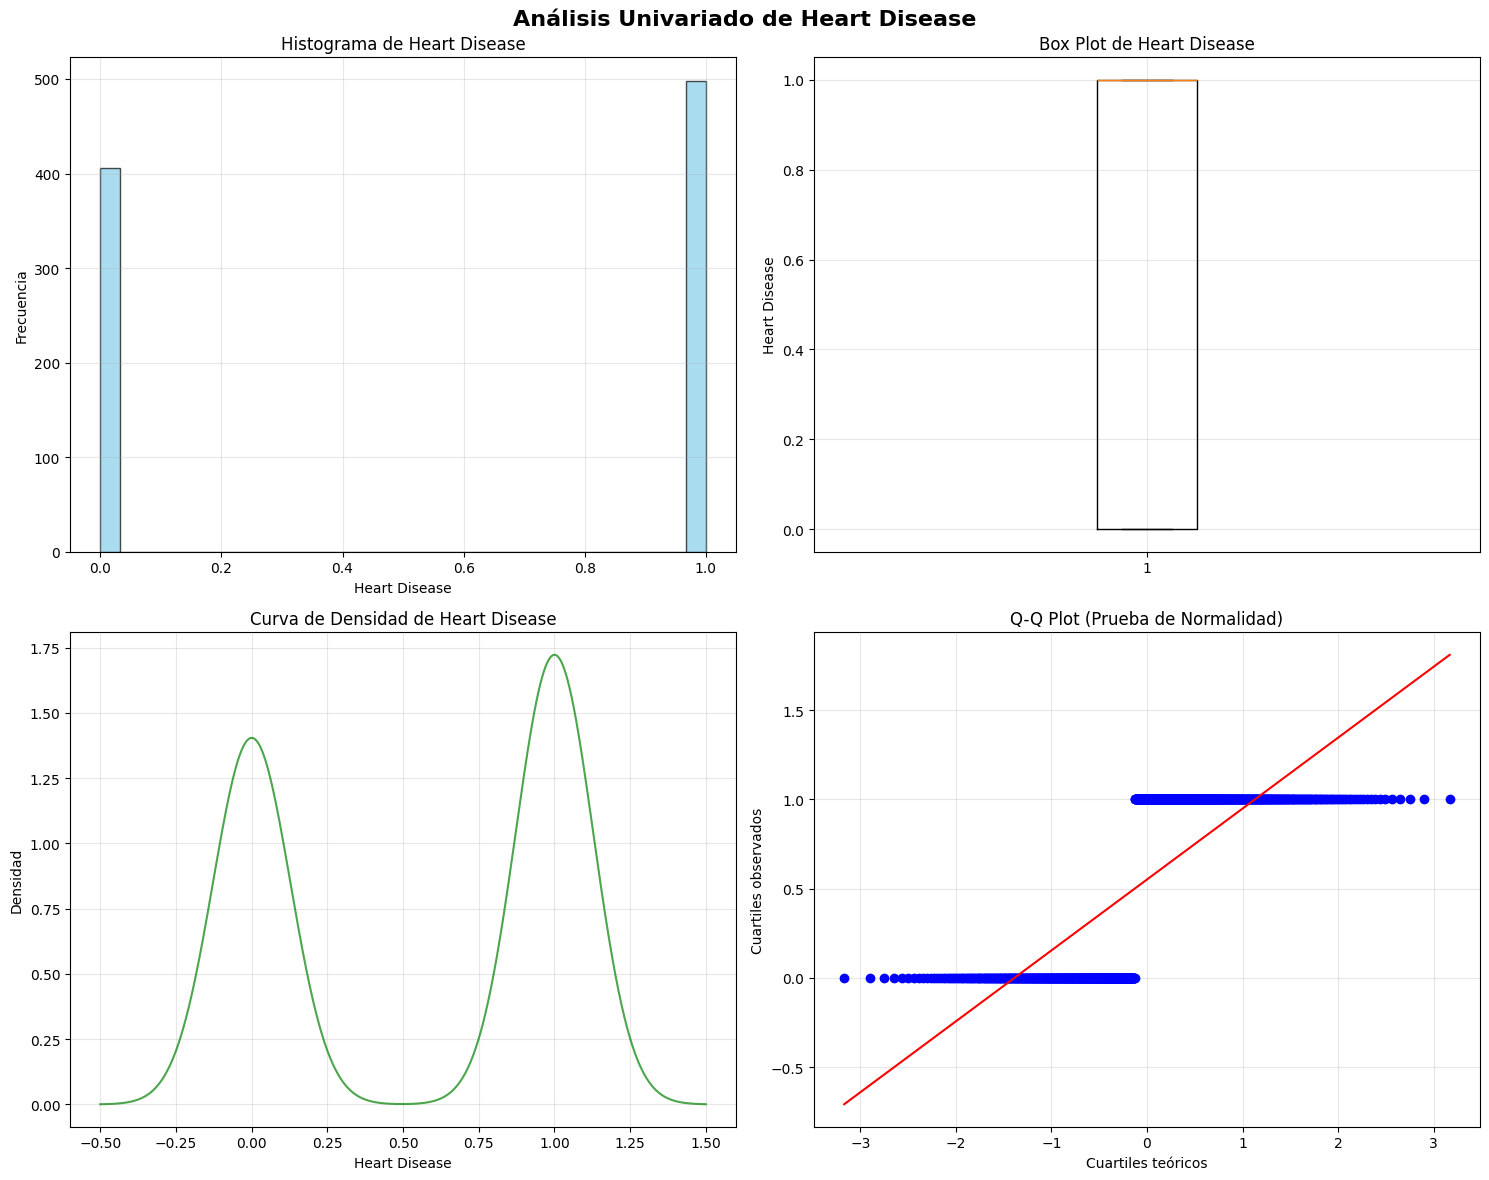

In [31]:
# Visualización de la distribución de HEART DISEASE
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis Univariado de Heart Disease', fontsize=16, fontweight='bold')

# Histograma
axes[0, 0].hist(df["HeartDisease"].dropna(), bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title("Histograma de Heart Disease")
axes[0, 0].set_xlabel("Heart Disease")
axes[0, 0].set_ylabel("Frecuencia")
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(df["HeartDisease"].dropna(), vert=True)
axes[0, 1].set_title("Box Plot de Heart Disease")
axes[0, 1].set_ylabel("Heart Disease")
axes[0, 1].grid(True, alpha=0.3)

# Gráfico de densidad
df["HeartDisease"].dropna().plot(kind='density', ax=axes[1, 0], color='green', alpha=0.7)
axes[1, 0].set_title("Curva de Densidad de Heart Disease")
axes[1, 0].set_xlabel("Heart Disease")
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q Plot para normalidad
stats.probplot(df["HeartDisease"].dropna(), dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Prueba de Normalidad)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlabel('Cuartiles teóricos')
axes[1, 1].set_ylabel('Cuartiles observados')

plt.tight_layout()
plt.show()